# SVM

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.svm import SVC

In [4]:
from sklearn.svm import LinearSVC

In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [6]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [7]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

importamos las librerias

## Cargado de datos

In [8]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 15), (42539, 15), (170152, 1), (42539, 1))

In [10]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

cargamos los datos

## Funciones usadas

In [11]:
from funciones import *

## Modelo SVC

In [11]:
pipe_SVC = crear_pipeline(SVC(kernel='rbf', C=1.0, gamma='scale', probability=True), tipo="normal")

In [12]:
start = time.time()
model_pipe = pipe_SVC.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 461.75 minutos


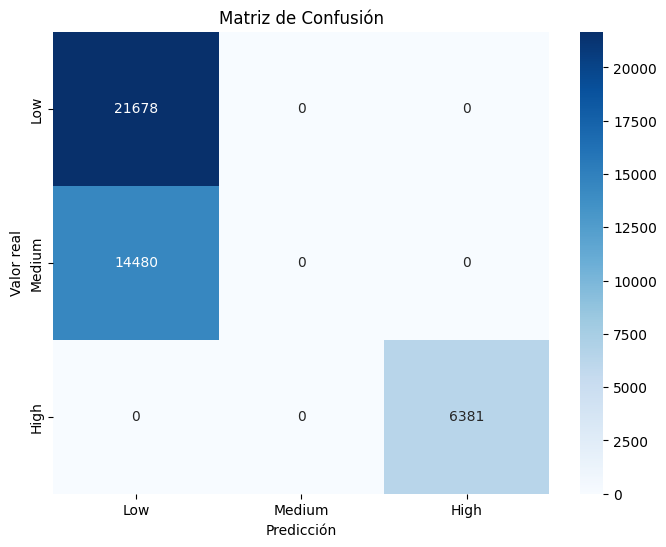


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      1.00      0.75     21678
      Medium       0.00      0.00      0.00     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.66     42539
   macro avg       0.53      0.67      0.58     42539
weighted avg       0.46      0.66      0.53     42539



{'Accuracy': 0.6596064787606667,
 'Precision (macro)': 0.5331784575105555,
 'Recall (macro)': 0.6666666666666666,
 'F1-score (macro)': 0.5832123014500773,
 'ROC-AUC': 0.7564573704115531}

In [13]:
evaluar_modelo(model_pipe, X_test, y_test)

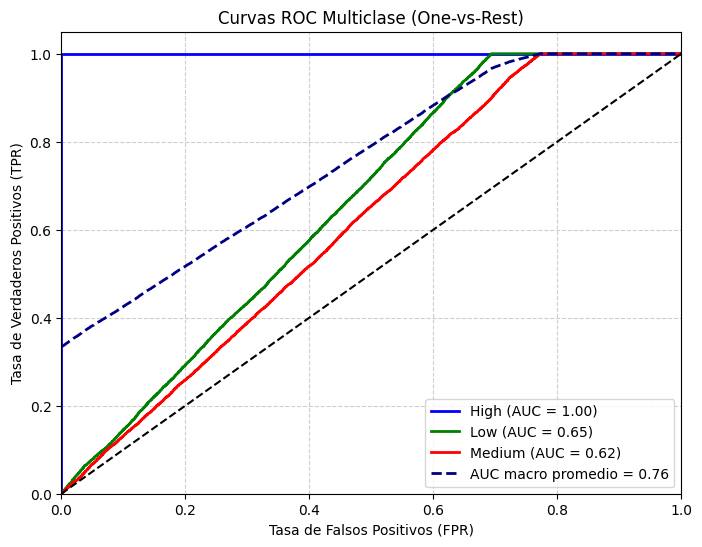


===== AUC por clase =====
High: 1.0000
Low: 0.6542
Medium: 0.6152
AUC macro promedio: 0.7565


({0: 1.0, 1: 0.6542137969367878, 2: 0.6151583142978716}, 0.7564720836789891)

In [14]:
plot_roc_multiclass(model_pipe, X_test, y_test)

El modelo presenta un **excelente desempeño en la clase *High*** con un AUC perfecto de **1.0000**, indicando una separación completa entre las observaciones positivas y negativas.  
Las clases *Low* (0.6542) y *Medium* (0.6152) muestran un rendimiento **moderado**, lo que sugiere que el modelo aún tiene cierta dificultad para discriminar entre estas categorías.  
El **AUC macro promedio de 0.7565** refleja un rendimiento general **sólido y equilibrado**, evidenciando una mejora respecto a versiones anteriores y una mejor capacidad de generalización global.

## Balanceo de modelo

### SMOTE

In [16]:
pipe_SVC_bal = crear_pipeline(SVC(kernel='rbf', C=1.0, gamma='scale', probability=True), tipo="balanceo_smote")

In [17]:
start = time.time()
model_pipe_bal = pipe_SVC_bal.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 485.55 minutos


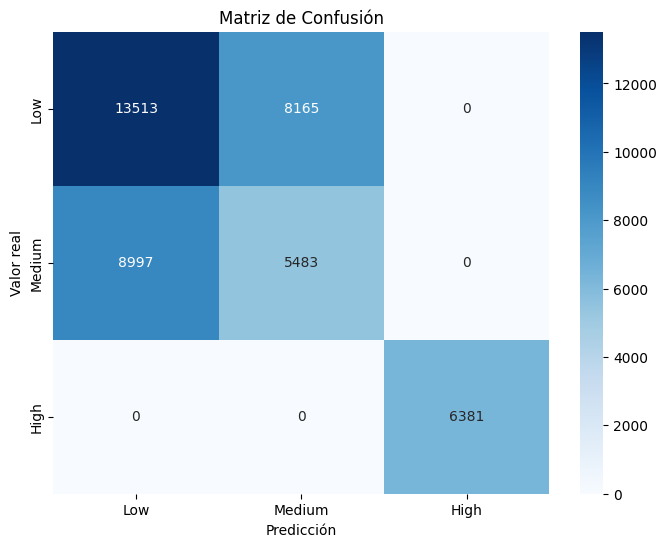


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.62      0.61     21678
      Medium       0.40      0.38      0.39     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.60     42539
   macro avg       0.67      0.67      0.67     42539
weighted avg       0.59      0.60      0.59     42539



{'Accuracy': 0.5965584522438233,
 'Precision (macro)': 0.6673516060509949,
 'Recall (macro)': 0.6673370278733929,
 'F1-score (macro)': 0.6671582166472559,
 'ROC-AUC': 0.7567071895764254}

In [18]:
evaluar_modelo(model_pipe_bal, X_test, y_test)

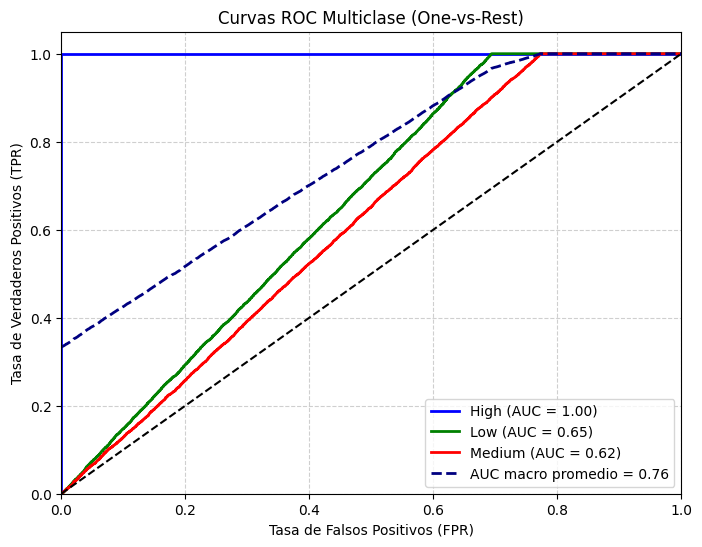


===== AUC por clase =====
High: 1.0000
Low: 0.6546
Medium: 0.6155
AUC macro promedio: 0.7567


({0: 1.0, 1: 0.6545848292543064, 2: 0.6155367394749698}, 0.7567219480926943)

In [19]:
plot_roc_multiclass(model_pipe_bal, X_test, y_test)

El modelo Smote actual mantiene el rendimiento perfecto para la clase High y presenta ligeras mejoras en las clases Low y Medium, lo que se refleja en un incremento mínimo del AUC macro promedio (de 0.7565 a 0.7567).
Aunque la mejora es marginal, indica una mayor estabilidad y consistencia del modelo al clasificar las tres categorías, especialmente en los casos menos representados.

### ADASYN

In [20]:
pipe_SVC_ads = crear_pipeline(SVC(kernel='rbf', C=1.0, gamma='scale', probability=True), tipo="balanceo_adasyn")

In [21]:
start = time.time()
model_pipe_ads = pipe_SVC_ads.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 344.86 minutos


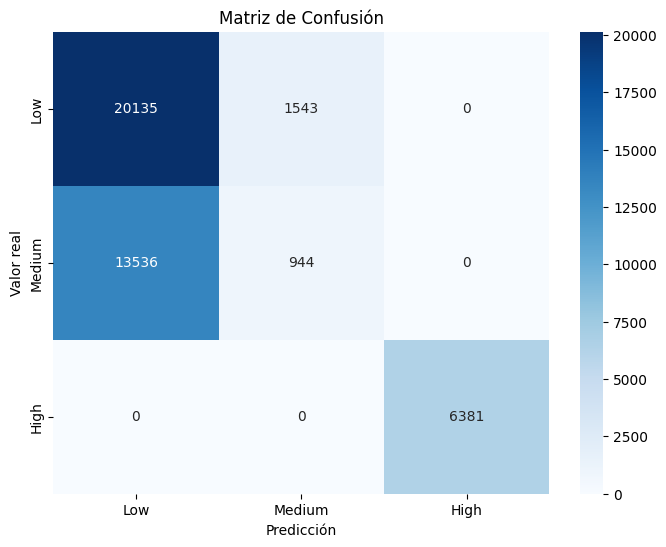


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.93      0.73     21678
      Medium       0.38      0.07      0.11     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.65     42539
   macro avg       0.66      0.66      0.61     42539
weighted avg       0.58      0.65      0.56     42539



{'Accuracy': 0.6455252826817743,
 'Precision (macro)': 0.6591887070983403,
 'Recall (macro)': 0.664671739066535,
 'F1-score (macro)': 0.6129466381999906,
 'ROC-AUC': 0.7541789640630358}

In [22]:
evaluar_modelo(model_pipe_ads, X_test, y_test)

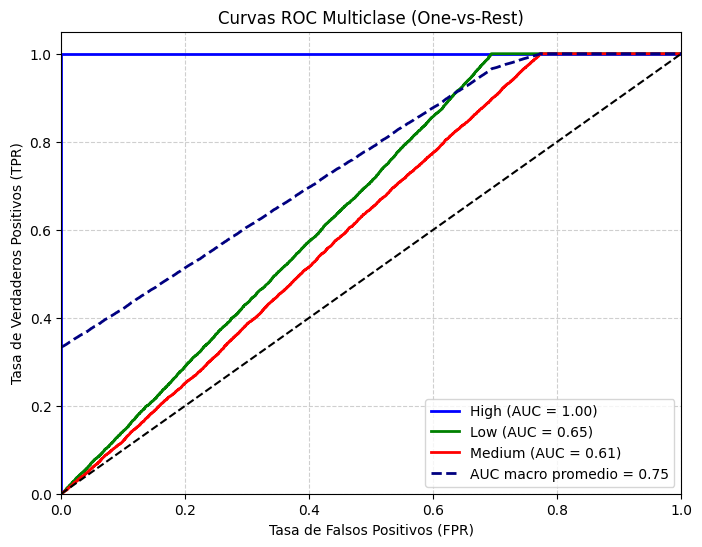


===== AUC por clase =====
High: 1.0000
Low: 0.6510
Medium: 0.6115
AUC macro promedio: 0.7542


({0: 1.0, 1: 0.6509952270238155, 2: 0.6115416651652921}, 0.7541937667862052)

In [23]:
plot_roc_multiclass(model_pipe_ads, X_test, y_test)

El nuevo modelo mantiene un rendimiento perfecto en la clase High, pero muestra una ligera disminución en las clases Low y Medium, lo que reduce el AUC macro promedio en 0.0025 puntos.
Aunque la caída es leve, sugiere que el modelo anterior ofrecía una mayor capacidad de generalización, especialmente para las clases minoritarias.

## Optimizacion computacional

In [12]:

pipe_SVM_opt = crear_pipeline(
    LinearSVC(C=1.0,               
        penalty='l2',       
        loss='squared_hinge',
        max_iter=5000,      
        random_state=0),
    tipo="balanceo_smote",
)

In [13]:
start = time.time()
model_pipe_opt = pipe_SVM_opt.fit(X_train, y_train)
end = time.time()

print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.16 minutos


In [16]:
y_scores = model_pipe_opt.decision_function(X_test)
classes = model_pipe_opt.classes_

roc_aucs = {}

for i, cls in enumerate(classes):
    binary_true = (y_test == cls).astype(int)
    roc_aucs[cls] = roc_auc_score(binary_true, y_scores[:, i])

roc_aucs

{'High': 0.959238592737464,
 'Low': 0.6369075662151163,
 'Medium': 0.6077575413803471}

In [17]:
roc_auc_macro = np.mean(list(roc_aucs.values()))
print("ROC-AUC macro:", roc_auc_macro)

ROC-AUC macro: 0.7346345667776425


Calculamos roc manualmente dado que nuestra funcion no es compatible con el modelo LinearSVC

[Aviso] No se pudo calcular AUC: This 'Pipeline' has no attribute 'predict_proba'


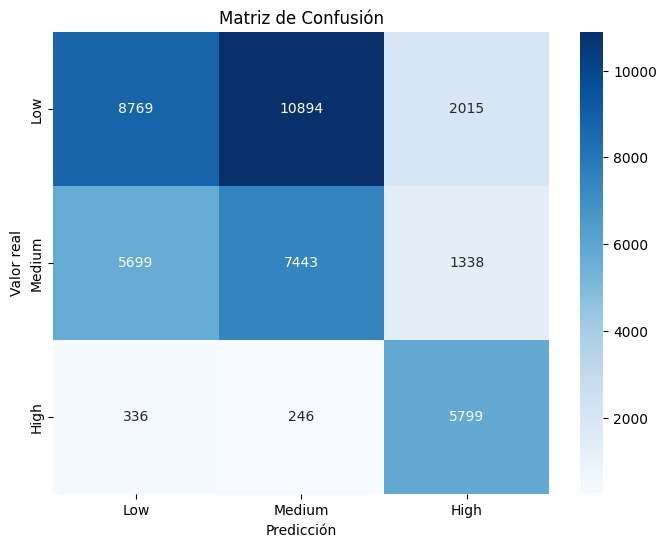


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.40      0.48     21678
      Medium       0.40      0.51      0.45     14480
        High       0.63      0.91      0.75      6381

    accuracy                           0.52     42539
   macro avg       0.54      0.61      0.56     42539
weighted avg       0.53      0.52      0.51     42539



{'Accuracy': 0.5174310632595971,
 'Precision (macro)': 0.5421664216198195,
 'Recall (macro)': 0.6091075162503112,
 'F1-score (macro)': 0.5592099943428509,
 'ROC-AUC': None}

In [ ]:
evaluar_modelo(model_pipe_opt, X_test, y_test)

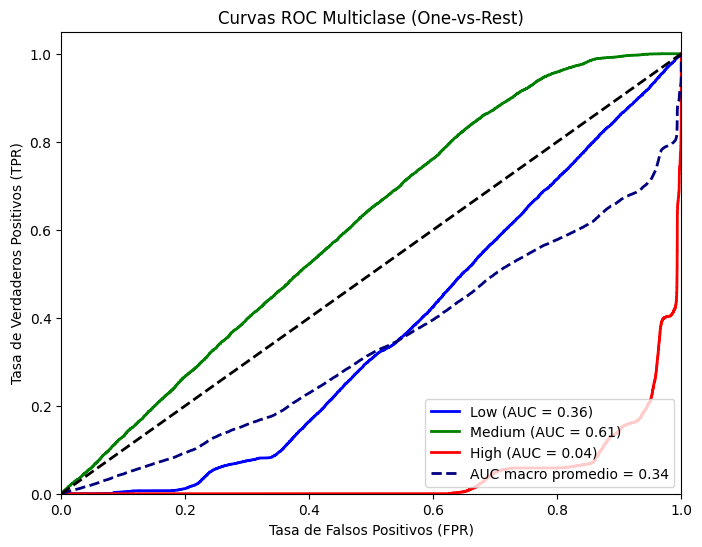

In [ ]:
plot_roc_multiclass2(model_pipe_opt, X_test, y_test)

Los resultados muestran un AUC macro promedio de 0.34, indicando un bajo desempeño general.

La clase High (0.04) presenta una capacidad casi nula para discriminar correctamente.

La clase Low (0.36) mejora ligeramente, pero sigue siendo débil.

La clase Medium (0.61) es la única con un rendimiento moderado.

En conjunto, el modelo no logra diferenciar bien entre las clases, lo que sugiere la necesidad de ajustar el preprocesamiento, el balance de clases o los hiperparámetros para mejorar la capacidad predictiva.

## Tabla Comparativa

| SVM      | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| SVC      | 0.66     | 0.53     | 0.67   | 0.58     | 0.76 | 461.75
| SMOTE     | 0.60     | 0.68     | 0.68   | 0.68     | 0.76 | 485.55
| ADASYN     | 0.65    | 0.66     | 0.66   | 0.61     | 0.75 |344.86 
| Optimizado    | 0.52     | 0.54     | 0.61   | 0.56     | 0.73 | 0.16